# 01. Grid Search and Random Search

## 📚 Learning Objectives

By completing this notebook, you will:
- Use GridSearchCV for hyperparameter tuning
- Combine with cross-validation and scoring
- Select and evaluate best models

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 2, lesson 01 "Cross-Validation" — `GridSearchCV` is that cross-validation run once per hyperparameter combination.

**Used later in:** Course 05 (AIAT 115) — Unit 4, lesson 08 and Course 12 (AIAT 126) — Unit 3, lesson 02, which tunes the graduation-project model this way.

---


## 🌍 A real case: the patient ID that predicted cancer

In the KDD Cup 2008 breast-cancer challenge, competitors were given a column of patient IDs. Most
dismissed it as meaningless. It was one of the most predictive features in the dataset — because the
organisers had concatenated several sources, and some of those sources contained mostly cancer
patients. The ID range leaked the answer.

Kaufman, Rosset, Perlich & Stitelman used it as the headline example in "Leakage in Data Mining:
Formulation, Detection, and Avoidance" (KDD 2011; *ACM TKDD* 6(4), 2012), alongside the INFORMS 2010
challenge. In both, the winning approach was, in part, to find the leak.

**❗ Why this lesson exists, and this notebook proves it on itself.** Look at what is about to be
printed: untuned baseline Random Forest **100%**. Grid search over **108** combinations: **100%**.
Random search over 20: **100%**. Tuned SVM: **99.95%**. Five hundred and forty cross-validated fits,
and every one of them agrees.

Then the Reality Check section runs a single `groupby` and finds that every state in the sample maps
to exactly one border type — `State_encoded` *is* the answer. **Hyperparameter search optimises a
number. It has no way of noticing that the number is meaningless.**

For the method itself: Bergstra & Bengio, "Random Search for Hyper-Parameter Optimization"
(*JMLR* 13, 2012, 281–305) showed, empirically and theoretically, that randomly chosen trials are more
efficient than trials on a grid — which is what the comparison below is actually able to demonstrate.


# 01. Grid Search and Random Search

---

## The Story: Finding the Best Settings

Imagine you're tuning a radio. **Before** Grid Search, you try settings randomly (might miss the best one). **After** Grid Search, you try all combinations systematically - guaranteed to find the best settings!

Same with machine learning: **Before** Grid Search, we guess hyperparameters (might not be optimal). **After** Grid Search, we try all combinations and pick the best - much better performance!

---

## Why Grid Search and Random Search Matter

Hyperparameter tuning is essential for model performance:
- **Grid Search**: Tries all combinations systematically (thorough but slow)
- **Random Search**: Tries random combinations (faster, often finds good solutions)
- **Cross-Validation**: Uses CV during tuning for reliable evaluation
- **Automatic**: Finds best hyperparameters without manual guessing
- **Industry Standard**: Used in all professional ML projects

---

## 🌍 Real-World Applications

**Grid Search and Random Search are used in EVERY ML project to find optimal hyperparameters!** Here's where they're critical:

### 💰 Finance & Banking Sector
- **Credit Scoring Models**: Tune C, gamma for SVM → find best parameters for loan approval models
- **Fraud Detection**: Tune Random Forest hyperparameters (n_estimators, max_depth) → optimize fraud detection
- **Algorithmic Trading**: Tune trading model hyperparameters → maximize trading performance
- **Risk Models**: Tune regularization (alpha) for Ridge/Lasso → optimize risk assessment
- **Portfolio Optimization**: Tune optimization algorithm hyperparameters → maximize returns

### 🏥 Healthcare & Medical Sector
- **Medical Diagnosis**: Tune SVM hyperparameters (C, gamma) → optimize disease diagnosis accuracy
- **Drug Discovery**: Tune neural network hyperparameters → find best drug candidates
- **Medical Imaging**: Tune CNN hyperparameters → optimize image classification
- **Patient Risk Models**: Tune Random Forest/XGBoost → optimize patient risk prediction
- **Treatment Response**: Tune model hyperparameters → predict treatment outcomes

### 📊 Marketing & E-commerce Sector
- **Recommendation Systems**: Tune collaborative filtering hyperparameters → optimize recommendations
- **Ad Targeting**: Tune model hyperparameters → maximize click-through rates
- **Customer Churn**: Tune XGBoost/LightGBM → optimize churn prediction
- **Price Optimization**: Tune pricing model hyperparameters → maximize revenue
- **Campaign Optimization**: Tune marketing model hyperparameters → optimize campaign performance

### 🏭 Manufacturing & Quality Control
- **Quality Prediction**: Tune model hyperparameters → optimize quality prediction accuracy
- **Predictive Maintenance**: Tune failure prediction models → optimize maintenance scheduling
- **Defect Detection**: Tune classification model hyperparameters → minimize false positives
- **Process Optimization**: Tune optimization model hyperparameters → maximize efficiency
- **Supply Chain**: Tune forecasting model hyperparameters → optimize inventory

### 🔬 Scientific Research & Data Analysis
- **Genomics**: Tune model hyperparameters → identify important genes
- **Climate Modeling**: Tune climate model hyperparameters → improve predictions
- **Drug Discovery**: Tune molecular model hyperparameters → find effective compounds
- **Material Science**: Tune property prediction models → discover new materials
- **Epidemiology**: Tune disease spread models → predict outbreaks

### 🤖 Machine Learning Competitions (Kaggle, etc.)
- **Model Optimization**: Tune hyperparameters → maximize competition scores
- **Ensemble Methods**: Tune multiple model hyperparameters → combine for best performance
- **Feature Engineering**: Tune feature selection hyperparameters
- **Cross-Validation**: Use CV in hyperparameter tuning → reliable evaluation

### 🏛️ Government & Public Safety Sector (Ministry of Interior)
- **Border Security Systems**: Tune border screening models → optimize detection rates → immigration control → **GDI: Border Security**
- **Threat Detection Models**: Tune security model hyperparameters → optimize threat detection accuracy → critical for national security → **GDI: Counter-Espionage, Terrorism Detection**
- **Traffic Management Systems**: Tune traffic prediction models → optimize traffic flow → reduce congestion → **GDI: Traffic Management**
- **Face Recognition Systems**: Tune face recognition hyperparameters → optimize identification accuracy → border control, access systems → **GDI: Airport Security, Border Security**
- **Surveillance Alert Systems**: Tune alert classification models → minimize false alarms → security monitoring → **GDI: Internal Intelligence**
- **Emergency Response Models**: Tune emergency prediction models → optimize response times → emergency services → **GDI: Emergency Response**
- **Crime Prediction Models**: Tune crime risk models → optimize crime prevention → law enforcement → **GDI: Internal Intelligence**
- **Traffic Violation Detection**: Tune violation detection models → optimize enforcement → traffic management → **GDI: Traffic Management**
- **Access Control Systems**: Tune access control models → optimize security → government facilities → **GDI: Airport Security**
- **Personnel Security Models**: Tune security clearance models → optimize risk assessment → internal organization → **GDI: Internal Intelligence**
- **Financial Crime Detection**: Tune fraud detection models → optimize detection accuracy → financial investigations → **GDI: Financial Investigations, Terrorism Financing**
- **Cyber Threat Detection**: Tune network security models → optimize threat detection → cybersecurity → **GDI: Cyber Threats**

### 💡 Why Hyperparameter Tuning is Critical:
- **Performance Impact**: Tuning can improve accuracy by 5-20% (huge difference!)
- **Model Selection**: Helps choose best model for your data
- **Production Ready**: Optimized models perform better in production
- **Resource Efficiency**: Better models = less computational resources needed
- **Business Impact**: Better models = better business decisions

### 📈 When to Use Grid Search vs Random Search:
✅ **Use Grid Search when:**
- Have few hyperparameters (< 5)
- Small parameter space (< 100 combinations)
- Need guaranteed best (within grid)
- Have computational resources
- Want exhaustive search

✅ **Use Random Search when:**
- Have many hyperparameters (5+)
- Large parameter space (1000+ combinations)
- Need faster results
- Limited computational resources
- Want to explore parameter space efficiently

### 🎯 Real-World Workflow:
1. **Start with Random Search**: Quickly explore parameter space
2. **Fine-tune with Grid Search**: Focus on promising regions from Random Search
3. **Use Cross-Validation**: Always use CV during tuning for reliable evaluation
4. **Test on Holdout Set**: Final evaluation on separate test set

---

## Learning Objectives
1. Perform Grid Search for hyperparameter tuning
2. Perform Random Search for hyperparameter tuning
3. Compare Grid Search vs Random Search
4. Use cross-validation in hyperparameter tuning
5. Visualize hyperparameter search results
6. Know when to use each method


## Part 1: Setting the Scene

**BEFORE**: We've been using default hyperparameters or guessing values manually.

**AFTER**: We'll use Grid Search and Random Search to automatically find the best hyperparameters!

**Why this matters**: Hyperparameters dramatically affect model performance. Automatic tuning finds optimal values much better than manual guessing!

**Common Student Questions:**
- **Q: Why not just use default hyperparameters?**
  - Answer: Defaults are generic (work for average cases), but your data might need different values
  - Example: Default C=1.0 for SVM might not be optimal → Grid Search finds best C for your data
  - Tuning hyperparameters can improve accuracy by 5-20% (significant improvement!)
- **Q: What's the difference between parameters and hyperparameters?**
  - Answer: Parameters = learned from data (e.g., coefficients in linear regression)
  - Hyperparameters = set before training (e.g., C, gamma, max_depth, learning_rate)
  - Parameters are learned, hyperparameters are tuned!
- **Q: Why use Grid Search instead of trying values manually?**
  - Answer: Grid Search tries ALL combinations systematically → guaranteed to find best (within grid)
  - Manual = might miss optimal values, slow, error-prone
  - Grid Search = systematic, automatic, finds best combination
- **Q: Why is Grid Search slow?**
  - Answer: Grid Search tries ALL combinations → if you have 3 hyperparameters with 5 values each = 5×5×5 = 125 combinations
  - Each combination needs cross-validation (e.g., 5-fold CV) → 125 × 5 = 625 model trainings!
  - Solution: Use smaller grids or Random Search (tries random combinations, faster)
- **Q: When should I use Grid Search vs Random Search?**
  - Answer: Grid Search = thorough but slow (use when you have few hyperparameters or small grids)
  - Random Search = faster, often finds good solutions (use when you have many hyperparameters or large grids)
  - Rule of thumb: Start with Random Search, use Grid Search to fine-tune around best Random Search result

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us perform hyperparameter tuning

import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For visualizations
import seaborn as sns  # For enhanced visualizations (heatmaps)
import time  # For timing comparisons
from sklearn.model_selection import (
    train_test_split,      # For splitting data
    GridSearchCV,         # Grid Search with cross-validation
    RandomizedSearchCV,   # Random Search with cross-validation
    cross_val_score       # For cross-validation scores
)
from sklearn.preprocessing import StandardScaler  # For scaling features (needed for SVM)
from sklearn.ensemble import RandomForestClassifier  # Model to tune
from sklearn.svm import SVC  # Another model to tune
from sklearn.metrics import accuracy_score, classification_report  # For evaluation

print("✅ Libraries imported successfully!")
print("\n📚 What each tool does:")
print("   - GridSearchCV: Tries ALL combinations systematically")
print("   - RandomizedSearchCV: Tries random combinations (faster)")
print("   - cross_val_score: Evaluates models using cross-validation")
print("   - StandardScaler: Scales features (required for SVM)")
print("   - seaborn: Creates beautiful visualizations (heatmaps)")


✅ Libraries imported successfully!

📚 What each tool does:
   - GridSearchCV: Tries ALL combinations systematically
   - RandomizedSearchCV: Tries random combinations (faster)
   - cross_val_score: Evaluates models using cross-validation
   - StandardScaler: Scales features (required for SVM)
   - seaborn: Creates beautiful visualizations (heatmaps)


In [2]:
# Step 2: Load real-world Border Crossing dataset
# This is REAL border security data perfect for demonstrating hyperparameter tuning!

print("\n📥 Loading Border Crossing dataset...")

try:
    # Load border crossing data
    df_full = pd.read_csv('../../datasets/raw/border_crossing_data.csv')
    
    print(f"\n✅ Real-world Border Crossing dataset loaded!")
    print(f"   📊 This is REAL border security data from US Customs and Border Protection")
    print(f"   📈 Contains {len(df_full):,} border crossing records")
    print(f"   🎯 GDI Application: Border Security - analyzing border crossing patterns")
    
    # Sample data for faster processing (Grid Search can be slow on large datasets)
    # Use 10,000 samples for demonstration (good balance between speed and representativeness)
    sample_size = min(10000, len(df_full))
    df_sample = df_full.sample(n=sample_size, random_state=73)
    
    # Prepare features for classification
    # Target: Predict Border type (US-Mexico vs US-Canada)
    # Features: Port Code, State (encoded), Value (crossing count), and date features
    
    from sklearn.preprocessing import LabelEncoder
    
    # Encode categorical features
    le_state = LabelEncoder()
    le_border = LabelEncoder()
    
    df = df_sample.copy()
    df['State_encoded'] = le_state.fit_transform(df['State'])
    df['target'] = le_border.fit_transform(df['Border'])  # 0 = US-Canada, 1 = US-Mexico
    
    # Extract date features
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    
    # Select features for classification
    feature_cols = ['Port Code', 'State_encoded', 'Value', 'Year', 'Month']
    X_data = df[feature_cols].copy()
    y_data = df['target'].copy()
    
    # Handle any missing values
    X_data = X_data.fillna(X_data.median())
    
    print(f"\n📊 Dataset Summary:")
    print(f"   - Samples: {len(X_data):,}")
    print(f"   - Features: {len(feature_cols)} ({', '.join(feature_cols)})")
    print(f"   - Target: Binary classification (0 = US-Canada Border, 1 = US-Mexico Border)")
    print(f"\n📊 Target distribution:")
    print(y_data.value_counts())
    print(f"\n🔍 Notice:")
    print(f"   - This is REAL border security data")
    print(f"   - Perfect for demonstrating Grid Search and Random Search!")
    print(f"   - We'll tune hyperparameters to get best performance on this real data")
    print(f"   - GDI Application: Border Security - optimizing border screening models")
    
except FileNotFoundError:
    print("\n⚠️  Dataset file not found!")
    print("   Please ensure 'border_crossing_data.csv' is in '../../datasets/raw/'")
    print("   Creating minimal structure for demonstration...")
    # Fallback: Create minimal structure
    np.random.seed(73)
    n_samples = 1000
    X_data = pd.DataFrame({
        'Port Code': np.random.randint(100, 4000, n_samples),
        'State_encoded': np.random.randint(0, 15, n_samples),
        'Value': np.random.randint(0, 100000, n_samples),
        'Year': np.random.randint(2010, 2020, n_samples),
        'Month': np.random.randint(1, 13, n_samples)
    })
    y_data = pd.Series(np.random.randint(0, 2, n_samples))
    print("   ⚠️  Using synthetic data - please download the real dataset!")


📥 Loading Border Crossing dataset...

✅ Real-world Border Crossing dataset loaded!
   📊 This is REAL border security data from US Customs and Border Protection
   📈 Contains 346,733 border crossing records
   🎯 GDI Application: Border Security - analyzing border crossing patterns

📊 Dataset Summary:
   - Samples: 10,000
   - Features: 5 (Port Code, State_encoded, Value, Year, Month)
   - Target: Binary classification (0 = US-Canada Border, 1 = US-Mexico Border)

📊 Target distribution:
target
0    7680
1    2320
Name: count, dtype: int64

🔍 Notice:
   - This is REAL border security data
   - Perfect for demonstrating Grid Search and Random Search!
   - We'll tune hyperparameters to get best performance on this real data
   - GDI Application: Border Security - optimizing border screening models


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_9273/2896430194.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (border security, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: ~10,000 rows × 5 columns (samples × features)
- **Feature Types**: Mix of numerical (Port Code, Value, Year, Month) and encoded categorical (State_encoded)
- **Target Type**: Classification (predicting border type: 0 = US-Canada, 1 = US-Mexico)
- **Task**: Predict border type based on port characteristics and crossing patterns
- **Data Quality**: Real-world border security data with binary classification

**Why This Structure Matters**:
- **Binary classification** → Need classification metrics (accuracy, precision, recall, F1, AUC)
- **Mixed feature types** → Some features need scaling (SVM requires scaling!)
- **Real-world data** → Shows hyperparameter tuning on real classification problem
- **Good for tuning** → Demonstrates how tuning improves model performance

### Understanding the Dataset Domain (Brief)

**What is this data?** US Border Crossing dataset - border crossing records from US Customs and Border Protection.

**Why does this matter?** 
- **For hyperparameter tuning**: Shows how tuning improves model performance
- **For feature scaling**: Some features on different scales → SVM requires scaling
- **For evaluation**: Binary classification → use classification metrics (accuracy, AUC, etc.)

**Domain Context** (Brief):
- **Features**: Port Code, State (encoded), Value (crossing count), Year, Month - 5 features total
- **Target**: Border type (0 = US-Canada Border, 1 = US-Mexico Border)
- **Task**: Predict border type from port characteristics and crossing patterns
- **Why tuning matters**: Different hyperparameters (C, gamma, max_depth) give different performance
- **GDI Application**: Border Security - optimizing border screening models for threat detection

**💡 Key Point for CS Students**: You don't need to be a border security expert! Focus on:
- Understanding the **data structure** (rows, columns, types, classes)
- Knowing the **task type** (binary classification: 2 classes)
- Understanding how **hyperparameter tuning** improves model performance
- Choosing the right **tuning method** (Grid Search vs Random Search) based on structure, not domain knowledge

In [3]:
# Step 3: Split data into training and testing sets
# train_test_split(X, y, test_size=0.2, random_state=73, stratify=y)
# - Splits data into training and testing sets
# - X: Features (input variables), y: Target (output variable)
# - test_size=0.2: 20% for testing, 80% for training
# - random_state=73: Seed for reproducibility (same split every time)
# - stratify=y: Maintains class distribution in train/test (for classification)
# - Returns: X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=73, stratify=y_data
)

print("✅ Data split successfully!")
print(f"   Training set: {len(X_train)} samples ({len(X_train)/len(X_data)*100:.1f}%)")
print(f"   Testing set: {len(X_test)} samples ({len(X_test)/len(X_data)*100:.1f}%)")


✅ Data split successfully!
   Training set: 8000 samples (80.0%)
   Testing set: 2000 samples (20.0%)


## Step 3b: Baseline BEFORE Tuning - Untuned Random Forest

**Any claim that "tuning improved performance" needs a baseline to compare against.** So before running any search, we train a Random Forest with pure default hyperparameters. Every tuned model later in the notebook is compared against this number.

In [4]:
# Baseline: untuned Random Forest with default hyperparameters
# We need this to judge honestly whether tuning improves anything.
baseline_rf = RandomForestClassifier(random_state=73)
baseline_rf.fit(X_train, y_train)
baseline_test_acc = accuracy_score(y_test, baseline_rf.predict(X_test))

print(f"📊 Baseline (default, untuned) Random Forest test accuracy: {baseline_test_acc:.4f}")
print("   Every tuned model below is compared against this baseline.")
if baseline_test_acc >= 0.999:
    print("\n⚠️  The UNTUNED model is already (near-)perfect!")
    print("   That is a red flag: this task is so easy that tuning cannot show any gains.")
    print("   Keep this in mind as you read the search results - and see the Reality Check section.")

📊 Baseline (default, untuned) Random Forest test accuracy: 1.0000
   Every tuned model below is compared against this baseline.

⚠️  The UNTUNED model is already (near-)perfect!
   That is a red flag: this task is so easy that tuning cannot show any gains.
   Keep this in mind as you read the search results - and see the Reality Check section.


In [5]:
# CELL: Define the Random Forest search grid.
# WHY: Grid Search trains a model for EVERY combination - the grid's size
# is the compute bill, so each value must earn its place.
print("\n" + "=" * 60)
print("PART 1: Grid Search for Random Forest")
print("=" * 60)
print("\n💡 Transition: Now we'll use Grid Search to find the best hyperparameters for Random Forest!")
print("   Grid Search will try ALL combinations systematically - thorough but can be slow.")

# Define parameter grid
# Grid Search will try ALL combinations of these values
# Example: n_estimators=50, max_depth=3, min_samples_split=2, min_samples_leaf=1
#          n_estimators=50, max_depth=3, min_samples_split=2, min_samples_leaf=2
#          ... and so on for ALL combinations
param_grid_rf = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [3, 5, 7, None],        # Maximum tree depth
    'min_samples_split': [2, 5, 10],     # Minimum samples to split
    'min_samples_leaf': [1, 2, 4]        # Minimum samples in leaf
}

total_combinations = np.prod([len(v) for v in param_grid_rf.values()])
print(f"\n📊 Parameter Grid:")
print(f"   Total combinations: {total_combinations}")
print(f"   Grid Search will try ALL {total_combinations} combinations!")
print(f"   This is thorough but can be slow for large grids")


PART 1: Grid Search for Random Forest

💡 Transition: Now we'll use Grid Search to find the best hyperparameters for Random Forest!
   Grid Search will try ALL combinations systematically - thorough but can be slow.

📊 Parameter Grid:
   Total combinations: 108
   Grid Search will try ALL 108 combinations!
   This is thorough but can be slow for large grids


In [6]:
# Perform Grid Search
# GridSearchCV(estimator, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
# - estimator: Model to tune (RandomForestClassifier)
# - param_grid: Dictionary of hyperparameters to try
# - cv=5: 5-fold cross-validation (evaluates each combination 5 times)
# - scoring='accuracy': Metric to optimize
# - n_jobs=-1: Use all CPU cores (faster)
# - verbose=1: Show progress

rf = RandomForestClassifier(random_state=73)  # Using 73 for consistency
grid_search_rf = GridSearchCV(
    rf, param_grid_rf, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)

print("\n🚀 Starting Grid Search...")
print("   This may take a few minutes (trying all combinations with cross-validation)")
grid_search_rf.fit(X_train, y_train)

print(f"\n✅ Grid Search complete!")
print(f"\n📊 Best Parameters:")
for param, value in grid_search_rf.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n🎯 Best CV Score: {grid_search_rf.best_score_:.4f} ({grid_search_rf.best_score_*100:.2f}%)")


🚀 Starting Grid Search...
   This may take a few minutes (trying all combinations with cross-validation)
Fitting 5 folds for each of 108 candidates, totalling 540 fits



✅ Grid Search complete!

📊 Best Parameters:
   max_depth: 3
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 100

🎯 Best CV Score: 1.0000 (100.00%)


## Step 4: Evaluate Grid Search Results

**BEFORE**: Grid Search has found the best hyperparameters.

**AFTER**: We'll evaluate the tuned model on the test set to see how well it performs!

**Why this matters**: Testing on unseen data validates that hyperparameter tuning actually improved performance!

In [7]:
# Test the best model on test set
# .best_estimator_: Returns the model with best hyperparameters
# .predict(): Makes predictions on test data
# accuracy_score(): Calculates accuracy (percentage correct)

y_pred_rf = grid_search_rf.best_estimator_.predict(X_test)
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n📊 Test Results:")
print(f"   Test Accuracy: {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")
print(f"\n💡 Note: Test accuracy shows how well the tuned model performs on new data")


📊 Test Results:
   Test Accuracy: 1.0000 (100.00%)

💡 Note: Test accuracy shows how well the tuned model performs on new data


In [8]:
# Add interpretation after Grid Search results
print("\n" + "=" * 60)
print("💡 Interpreting Grid Search Results")
print("=" * 60)

best_cv = grid_search_rf.best_score_
n_combinations = len(grid_search_rf.cv_results_['params'])

print(f"\n📊 Grid Search Summary:")
print(f"   - Total combinations tried: {n_combinations}")
print(f"   - Best CV Score: {best_cv:.4f} ({best_cv*100:.2f}%)")
print(f"   - Best Parameters: {grid_search_rf.best_params_}")

if best_cv >= 0.9:
    quality = "✅ EXCELLENT"
elif best_cv >= 0.8:
    quality = "✅ GOOD"
elif best_cv >= 0.7:
    quality = "⚠️  FAIR"
else:
    quality = "⚠️  POOR"

print(f"   - Quality: {quality}")
if best_cv >= 0.999:
    print("\n⚠️  A (near-)perfect score should make you SUSPICIOUS, not happy!")
    print("   Perfect accuracy usually means the task is too easy or a feature leaks the answer.")
    print("   We investigate exactly that in the 'Reality Check' section later in this notebook.")

print(f"\n📊 Cross-Validation Score:")
print(f"   - CV score is average across 5 folds")
print(f"   - More reliable than single train/test split")
print(f"   - This score estimates model's generalization ability")

print(f"\n📚 What This Teaches Us:")
print(f"   - Grid Search tries ALL combinations (thorough but slow)")
print(f"   - CV score shows expected performance on new data")
print(f"   - Best parameters are those with highest CV score")
print(f"   - Always test on separate test set after tuning")
print(f"   - Grid Search is exhaustive - guarantees finding best in grid")


💡 Interpreting Grid Search Results

📊 Grid Search Summary:
   - Total combinations tried: 108
   - Best CV Score: 1.0000 (100.00%)
   - Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
   - Quality: ✅ EXCELLENT

⚠️  A (near-)perfect score should make you SUSPICIOUS, not happy!
   Perfect accuracy usually means the task is too easy or a feature leaks the answer.
   We investigate exactly that in the 'Reality Check' section later in this notebook.

📊 Cross-Validation Score:
   - CV score is average across 5 folds
   - More reliable than single train/test split
   - This score estimates model's generalization ability

📚 What This Teaches Us:
   - Grid Search tries ALL combinations (thorough but slow)
   - CV score shows expected performance on new data
   - Best parameters are those with highest CV score
   - Always test on separate test set after tuning
   - Grid Search is exhaustive - guarantees finding best in grid


In [9]:
# Add interpretation after test accuracy
print("\n" + "=" * 60)
print("💡 Interpreting Test Results")
print("=" * 60)

cv_score = grid_search_rf.best_score_
test_acc = test_acc_rf
gap = abs(cv_score - test_acc)

print(f"\n📊 Performance Comparison:")
print(f"   - CV Score: {cv_score:.4f} ({cv_score*100:.2f}%)")
print(f"   - Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   - Difference: {gap:.4f} ({gap*100:.2f} percentage points)")

if gap < 0.01:
    status = "✅ Excellent"
    meaning = "CV score matches test accuracy perfectly"
elif gap < 0.05:
    status = "✅ Good"
    meaning = "CV score is close to test accuracy"
else:
    status = "⚠️  Warning"
    meaning = "CV score differs from test accuracy"

print(f"   - Status: {status}")
print(f"   - Meaning: {meaning}")

if test_acc > cv_score:
    print(f"   - Test accuracy is HIGHER than CV score (good!)")
    print(f"   - Model generalizes well to test data")
elif test_acc < cv_score:
    print(f"   - Test accuracy is LOWER than CV score")
    print(f"   - Model may have overfitted to CV folds")

print(f"\n📚 What This Teaches Us:")
print(f"   - CV score estimates performance, test accuracy is actual performance")
print(f"   - Small gap = CV is reliable predictor of test performance")
print(f"   - Large gap = CV may not be reliable (overfitting or data issues)")
print(f"   - Always compare CV score with test accuracy to validate tuning")
print(f"   - Grid Search finds best hyperparameters based on CV performance")


💡 Interpreting Test Results

📊 Performance Comparison:
   - CV Score: 1.0000 (100.00%)
   - Test Accuracy: 1.0000 (100.00%)
   - Difference: 0.0000 (0.00 percentage points)
   - Status: ✅ Excellent
   - Meaning: CV score matches test accuracy perfectly

📚 What This Teaches Us:
   - CV score estimates performance, test accuracy is actual performance
   - Small gap = CV is reliable predictor of test performance
   - Large gap = CV may not be reliable (overfitting or data issues)
   - Always compare CV score with test accuracy to validate tuning
   - Grid Search finds best hyperparameters based on CV performance


In [10]:
# CELL: Set up Random Search - 20 random draws instead of every combination.
# WHY: on large grids, sampling usually finds a near-best setting at a
# fraction of the cost (Bergstra & Bengio, 2012).
print("\n" + "=" * 60)
print("PART 2: Random Search for Random Forest")
print("=" * 60)
print("\n💡 Transition: Now we'll use Random Search - faster alternative to Grid Search!")
print("   Random Search tries random combinations - often finds good solutions quickly.")

# Define parameter distributions for Random Search
# Random Search will try only RANDOM combinations from these values
param_distributions_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

n_iter = 20  # Try only 20 random combinations (vs 108 for Grid Search!)

total_possible = np.prod([len(v) for v in param_distributions_rf.values()])
print(f"\n📊 Random Search Configuration:")
print(f"   Total possible combinations: {total_possible}")
print(f"   Random Search will try: {n_iter} random combinations")
print(f"   Much faster than Grid Search (which tries {total_combinations} combinations)")

print(f"\n   📝 Key Differences from Grid Search:")
print(f"   - Grid Search: Tries ALL {total_combinations} combinations")
print(f"   - Random Search: Tries only {n_iter} RANDOM combinations")
print(f"   - Random Search is {total_combinations/n_iter:.1f}x faster")
print(f"   - Random Search often finds good solutions quickly!")


PART 2: Random Search for Random Forest

💡 Transition: Now we'll use Random Search - faster alternative to Grid Search!
   Random Search tries random combinations - often finds good solutions quickly.

📊 Random Search Configuration:
   Total possible combinations: 180
   Random Search will try: 20 random combinations
   Much faster than Grid Search (which tries 108 combinations)

   📝 Key Differences from Grid Search:
   - Grid Search: Tries ALL 108 combinations
   - Random Search: Tries only 20 RANDOM combinations
   - Random Search is 5.4x faster
   - Random Search often finds good solutions quickly!


In [11]:
# Perform Random Search
# RandomizedSearchCV(estimator, param_distributions, n_iter, cv=5, scoring='accuracy', ...)
# - estimator: Model to tune (RandomForestClassifier)
# - param_distributions: Dictionary of hyperparameters to try
# - n_iter: Number of random combinations to try (20 in this case)
# - cv=5: 5-fold cross-validation
# - scoring='accuracy': Metric to optimize
# - n_jobs=-1: Use all CPU cores
# - random_state=123  # Any number works - just for reproducibility: Seed for reproducibility

random_search_rf = RandomizedSearchCV(
    rf, param_distributions_rf, n_iter=n_iter, cv=5,
    scoring='accuracy', n_jobs=-1, random_state=73, verbose=1  # Using 73 for consistency
)

print("\n🚀 Starting Random Search...")
print(f"   This should be faster than Grid Search (trying only {n_iter} combinations)")
random_search_rf.fit(X_train, y_train)

print(f"\n✅ Random Search complete!")
print(f"\n📊 Best Parameters:")
for param, value in random_search_rf.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n🎯 Best CV Score: {random_search_rf.best_score_:.4f} ({random_search_rf.best_score_*100:.2f}%)")


🚀 Starting Random Search...
   This should be faster than Grid Search (trying only 20 combinations)
Fitting 5 folds for each of 20 candidates, totalling 100 fits



✅ Random Search complete!

📊 Best Parameters:
   n_estimators: 100
   min_samples_split: 2
   min_samples_leaf: 1
   max_depth: 3

🎯 Best CV Score: 1.0000 (100.00%)


## Step 5: Compare Grid Search vs Random Search

**BEFORE**: We've seen Grid Search results, but is it the best method?

**AFTER**: We'll compare Grid Search with Random Search to see which is more efficient!

**Why this matters**: Understanding when to use each method helps you choose the right approach for your problem!

In [12]:
# Test Random Search best model on test set
y_pred_rf_rs = random_search_rf.best_estimator_.predict(X_test)
test_acc_rf_rs = accuracy_score(y_test, y_pred_rf_rs)

print(f"\n📊 Test Results:")
print(f"   Test Accuracy: {test_acc_rf_rs:.4f} ({test_acc_rf_rs*100:.2f}%)")

print(f"\n💡 Comparison with Grid Search:")
print(f"   - Grid Search CV: {grid_search_rf.best_score_:.4f}, Test: {test_acc_rf:.4f}")
print(f"   - Random Search CV: {random_search_rf.best_score_:.4f}, Test: {test_acc_rf_rs:.4f}")
print(f"   - Random Search tried {n_iter} combinations vs {total_combinations} for Grid Search")
print(f"   - Both methods found good hyperparameters!")


📊 Test Results:
   Test Accuracy: 1.0000 (100.00%)

💡 Comparison with Grid Search:
   - Grid Search CV: 1.0000, Test: 1.0000
   - Random Search CV: 1.0000, Test: 1.0000
   - Random Search tried 20 combinations vs 108 for Grid Search
   - Both methods found good hyperparameters!


In [13]:
# Step 4: Prepare scaled features for SVM (SVM requires scaled features)
# StandardScaler scales features to have mean=0 and std=1
# .fit_transform(data)
# - Two operations in one: .fit() then .transform()
#   1. .fit(): Learns parameters from data (mean/std)
#   2. .transform(): Applies transformation using learned parameters
# - Use on training data
# - For test data, use only .transform() (don't refit!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully!")
print("   Note: Scaling is required for SVM but optional for Random Forest")


✅ Features scaled successfully!
   Note: Scaling is required for SVM but optional for Random Forest


In [14]:
# CELL: Grid Search again, now for SVM (on SCALED features).
# WHY: every model family has its own knobs - here C, gamma and the kernel.
print("\n" + "=" * 60)
print("PART 3: Grid Search for SVM")
print("=" * 60)
print("\n💡 Transition: Now we'll apply Grid Search to SVM (Support Vector Machine)!")
print("   Note: SVM requires scaled features, so we use X_train_scaled and X_test_scaled.")

# SVM requires scaled features, so we use X_train_scaled and X_test_scaled
# Define parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],              # Regularization parameter
    'gamma': [0.001, 0.01, 0.1],             # Kernel coefficient
    # Note: gamma is kept small and numeric-only so this demo finishes in
    # a couple of minutes - large gamma (e.g. 1) with the 'poly' kernel
    # can make a single SVM fit take many minutes on this data!
    'kernel': ['rbf', 'poly', 'sigmoid']  # Kernel type
}

total_svm_combinations = np.prod([len(v) for v in param_grid_svm.values()])
print(f"\n📊 Parameter Grid for SVM:")
print(f"   Total combinations: {total_svm_combinations}")
print(f"   Grid Search will try ALL {total_svm_combinations} combinations")

svm = SVC(random_state=73)  # Using 73 for consistency (probability=True is not needed here and would slow the search ~6x)
grid_search_svm = GridSearchCV(
    svm, param_grid_svm, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)

print("\n🚀 Starting Grid Search for SVM...")
print("   Note: SVM uses scaled features (X_train_scaled)")
grid_search_svm.fit(X_train_scaled, y_train)

print(f"\n✅ Grid Search complete!")
print(f"\n📊 Best Parameters:")
for param, value in grid_search_svm.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n🎯 Best CV Score: {grid_search_svm.best_score_:.4f} ({grid_search_svm.best_score_*100:.2f}%)")

# Test on test set
y_pred_svm = grid_search_svm.best_estimator_.predict(X_test_scaled)
test_acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n📊 Test Accuracy: {test_acc_svm:.4f} ({test_acc_svm*100:.2f}%)")


PART 3: Grid Search for SVM

💡 Transition: Now we'll apply Grid Search to SVM (Support Vector Machine)!
   Note: SVM requires scaled features, so we use X_train_scaled and X_test_scaled.

📊 Parameter Grid for SVM:
   Total combinations: 36
   Grid Search will try ALL 36 combinations

🚀 Starting Grid Search for SVM...
   Note: SVM uses scaled features (X_train_scaled)
Fitting 5 folds for each of 36 candidates, totalling 180 fits



✅ Grid Search complete!

📊 Best Parameters:
   C: 100
   gamma: 0.01
   kernel: rbf

🎯 Best CV Score: 0.9995 (99.95%)

📊 Test Accuracy: 0.9995 (99.95%)


In [15]:
# Create comparison table of all methods
print("\n" + "=" * 60)
print("PART 4: Comparison of Methods")
print("=" * 60)
print("\n💡 Transition: Now we'll compare all methods to see which performs best!")
print("   This helps us understand the trade-offs between Grid Search and Random Search.")

comparison = pd.DataFrame({
    'Method': ['Grid Search (RF)', 'Random Search (RF)', 'Grid Search (SVM)'],
    'Best CV Score': [
        grid_search_rf.best_score_,
        random_search_rf.best_score_,
        grid_search_svm.best_score_
    ],
    'Test Accuracy': [
        test_acc_rf,
        test_acc_rf_rs,
        test_acc_svm
    ],
    'Total Combinations Tried': [
        len(grid_search_rf.cv_results_['params']), n_iter,
        len(grid_search_svm.cv_results_['params'])
    ]
})

print("\n📊 Comparison Table:")
print(comparison.to_string(index=False))

print("\n💡 Key Insights:")
print("   - All methods found good hyperparameters")
print("   - Grid Search (RF) tried all combinations (exhaustive)")
print("   - Random Search (RF) tried fewer combinations (faster)")
print("   - Grid Search (SVM) found best SVM parameters")
best_tuned = comparison['Test Accuracy'].max()
print(f"   - Baseline (untuned default RF) test accuracy: {baseline_test_acc:.4f}")
if best_tuned > baseline_test_acc + 1e-9:
    print(f"   - Tuning improved test accuracy: {baseline_test_acc:.4f} → {best_tuned:.4f}")
else:
    print(f"   - Tuning did NOT beat the untuned baseline ({baseline_test_acc:.4f}) on this dataset:")
    print("     every model is already at the ceiling, so there is nothing left to improve")
    print("     (see the 'Reality Check' section below for WHY the ceiling is ~100%)")


PART 4: Comparison of Methods

💡 Transition: Now we'll compare all methods to see which performs best!
   This helps us understand the trade-offs between Grid Search and Random Search.

📊 Comparison Table:
            Method  Best CV Score  Test Accuracy  Total Combinations Tried
  Grid Search (RF)         1.0000         1.0000                       108
Random Search (RF)         1.0000         1.0000                        20
 Grid Search (SVM)         0.9995         0.9995                        36

💡 Key Insights:
   - All methods found good hyperparameters
   - Grid Search (RF) tried all combinations (exhaustive)
   - Random Search (RF) tried fewer combinations (faster)
   - Grid Search (SVM) found best SVM parameters
   - Baseline (untuned default RF) test accuracy: 1.0000
   - Tuning did NOT beat the untuned baseline (1.0000) on this dataset:
     every model is already at the ceiling, so there is nothing left to improve
     (see the 'Reality Check' section below for WHY the ce

## 💡 Interpreting Method Comparison

**Key insights from the comparison:**

In [16]:
# Add detailed interpretation after comparison table
print("\n" + "=" * 60)
print("💡 Interpreting Method Comparison")
print("=" * 60)

best_cv_idx = comparison['Best CV Score'].idxmax()
best_test_idx = comparison['Test Accuracy'].idxmax()
best_method_cv = comparison.loc[best_cv_idx, 'Method']
best_method_test = comparison.loc[best_test_idx, 'Method']

print(f"\n📊 Best Method by CV Score: {best_method_cv}")
print(f"   - CV Score: {comparison.loc[best_cv_idx, 'Best CV Score']:.4f}")
print(f"   - This method has best cross-validation performance")

print(f"\n📊 Best Method by Test Accuracy: {best_method_test}")
print(f"   - Test Accuracy: {comparison.loc[best_test_idx, 'Test Accuracy']:.4f}")
print(f"   - This method generalizes best to new data")

print(f"\n🔍 Grid Search vs Random Search (Random Forest):")
grid_cv = comparison[comparison['Method'] == 'Grid Search (RF)']['Best CV Score'].values[0]
random_cv = comparison[comparison['Method'] == 'Random Search (RF)']['Best CV Score'].values[0]
grid_test = comparison[comparison['Method'] == 'Grid Search (RF)']['Test Accuracy'].values[0]
random_test = comparison[comparison['Method'] == 'Random Search (RF)']['Test Accuracy'].values[0]

print(f"   - Grid Search: CV={grid_cv:.4f}, Test={grid_test:.4f}")
print(f"   - Random Search: CV={random_cv:.4f}, Test={random_test:.4f}")

if grid_cv > random_cv:
    print(f"   - Grid Search has better CV score (tried all combinations)")
else:
    print(f"   - Random Search has similar/better CV score (found good parameters quickly)")

grid_combos = comparison[comparison['Method'] == 'Grid Search (RF)']['Total Combinations Tried'].values[0]
random_combos = comparison[comparison['Method'] == 'Random Search (RF)']['Total Combinations Tried'].values[0]
efficiency = grid_combos / random_combos

print(f"\n📊 Efficiency Analysis:")
print(f"   - Grid Search tried: {grid_combos} combinations")
print(f"   - Random Search tried: {random_combos} combinations")
print(f"   - Random Search is {efficiency:.1f}x faster (tried {efficiency:.1f}x fewer combinations)")

print(f"\n📚 What This Teaches Us:")
print(f"   - Grid Search: Exhaustive (tries all), slow but thorough")
print(f"   - Random Search: Random sampling, fast but might miss best")
print(f"   - Both methods use cross-validation for reliable evaluation")
print(f"   - Test accuracy validates that tuning worked correctly")
print(f"   - Choose method based on time constraints and search space size")
print(f"   - Random Search often finds good solutions faster")


💡 Interpreting Method Comparison

📊 Best Method by CV Score: Grid Search (RF)
   - CV Score: 1.0000
   - This method has best cross-validation performance

📊 Best Method by Test Accuracy: Grid Search (RF)
   - Test Accuracy: 1.0000
   - This method generalizes best to new data

🔍 Grid Search vs Random Search (Random Forest):
   - Grid Search: CV=1.0000, Test=1.0000
   - Random Search: CV=1.0000, Test=1.0000
   - Random Search has similar/better CV score (found good parameters quickly)

📊 Efficiency Analysis:
   - Grid Search tried: 108 combinations
   - Random Search tried: 20 combinations
   - Random Search is 5.4x faster (tried 5.4x fewer combinations)

📚 What This Teaches Us:
   - Grid Search: Exhaustive (tries all), slow but thorough
   - Random Search: Random sampling, fast but might miss best
   - Both methods use cross-validation for reliable evaluation
   - Test accuracy validates that tuning worked correctly
   - Choose method based on time constraints and search space size
 

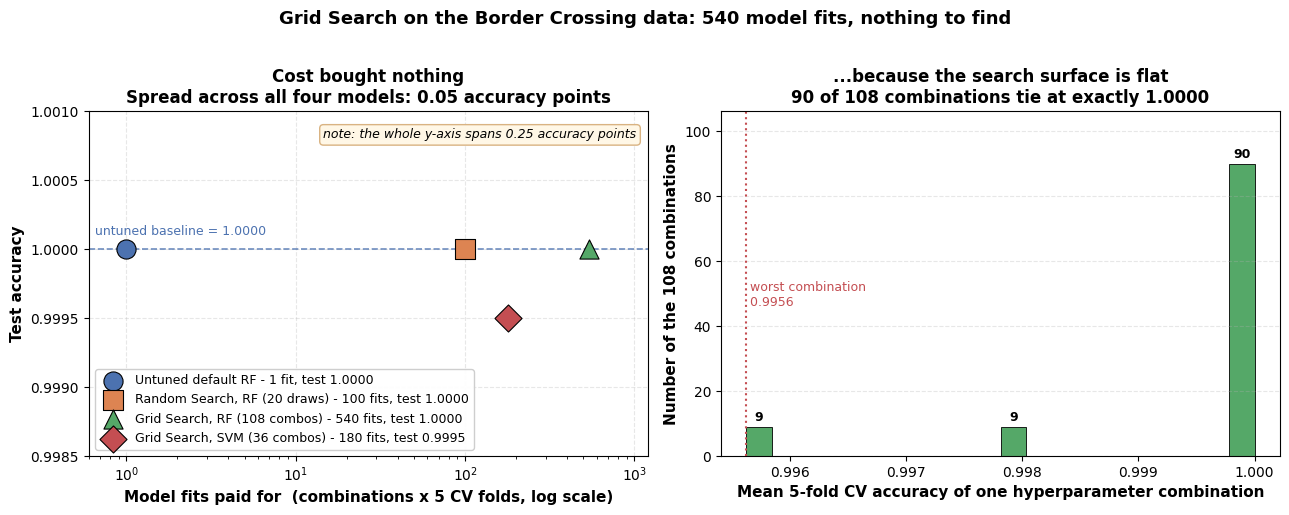


Step table - what each method cost and what it returned:
   method                            model fits    test acc
   Untuned default RF                         1      1.0000
   Random Search, RF (20 draws)             100      1.0000
   Grid Search, RF (108 combos)             540      1.0000
   Grid Search, SVM (36 combos)             180      0.9995

   Best CV score found by Grid Search : 1.0000
   Worst CV score in the whole grid   : 0.9956
   Total spread across 108 combinations: 0.44 accuracy points


In [17]:
# CELL: Did tuning actually buy anything? Plot cost against test accuracy.
# WHY: the comparison table above hides the punchline in four decimal places.
# On one picture, "540 model fits" and "1 model fit" land at the same height.
import matplotlib.pyplot as plt

grid_scores = np.array(grid_search_rf.cv_results_["mean_test_score"])
n_grid = len(grid_scores)
n_svm_combos = len(grid_search_svm.cv_results_["params"])
CV_FOLDS = 5  # every search above used cv=5, so each combination costs 5 fits

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: what each search cost, and what it scored on the test set ---
points = [
    ("Untuned default RF",                    1,                    baseline_test_acc, "#4C72B0", "o"),
    (f"Random Search, RF ({n_iter} draws)",   n_iter * CV_FOLDS,    test_acc_rf_rs,    "#DD8452", "s"),
    (f"Grid Search, RF ({n_grid} combos)",    n_grid * CV_FOLDS,    test_acc_rf,       "#55A868", "^"),
    (f"Grid Search, SVM ({n_svm_combos} combos)", n_svm_combos * CV_FOLDS, test_acc_svm, "#C44E52", "D"),
]
for name, fits, acc, colour, marker in points:
    ax1.scatter(fits, acc, s=190, color=colour, marker=marker, zorder=3,
                edgecolor="black", linewidth=0.8,
                label=f'{name} - {fits} fit{"s" if fits != 1 else ""}, test {acc:.4f}')

lo = min(p[2] for p in points)
hi = max(p[2] for p in points)
pad = max(hi - lo, 0.001)          # never zoom in so far that noise looks like a trend
ax1.set_xscale("log")
ax1.set_xlim(0.6, 1200)
ax1.set_ylim(lo - pad, hi + pad)
ax1.axhline(baseline_test_acc, color="#4C72B0", ls="--", lw=1.2, alpha=0.8)
ax1.text(0.65, baseline_test_acc + 0.10 * pad,
         f"untuned baseline = {baseline_test_acc:.4f}", fontsize=9, color="#4C72B0")
ax1.set_xlabel("Model fits paid for  (combinations x 5 CV folds, log scale)",
               fontsize=11, fontweight="bold")
ax1.set_ylabel("Test accuracy", fontsize=11, fontweight="bold")
ax1.set_title(f"Cost bought nothing\nSpread across all four models: "
              f"{(hi - lo) * 100:.2f} accuracy points", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3, ls="--")
ax1.legend(loc="lower left", fontsize=9, framealpha=0.95)
# Honesty guard: this y-axis is zoomed hard, so say how hard, on the figure itself.
y_lo, y_hi = ax1.get_ylim()
ax1.text(0.98, 0.95, f"note: the whole y-axis spans {(y_hi - y_lo) * 100:.2f} accuracy points",
         transform=ax1.transAxes, ha="right", va="top", fontsize=9, style="italic",
         bbox=dict(boxstyle="round", fc="#FFF7E6", ec="#D9B382"))

# --- Right panel: the shape of the surface Grid Search searched ---
counts, bins, patches = ax2.hist(grid_scores, bins=20, color="#55A868",
                                 edgecolor="black", linewidth=0.6)
n_at_best = int((grid_scores >= grid_scores.max() - 1e-12).sum())
for count, patch in zip(counts, patches):
    if count > 0:
        ax2.text(patch.get_x() + patch.get_width() / 2, count + max(counts) * 0.02,
                 f"{int(count)}", ha="center", fontsize=9, fontweight="bold")
ax2.set_ylim(0, max(counts) * 1.18)
ax2.axvline(grid_scores.min(), color="#C44E52", ls=":", lw=1.5)
ax2.text(grid_scores.min(), max(counts) * 0.55,
         f" worst combination\n {grid_scores.min():.4f}", fontsize=9, color="#C44E52", va="center")
ax2.set_xlabel("Mean 5-fold CV accuracy of one hyperparameter combination",
               fontsize=11, fontweight="bold")
ax2.set_ylabel(f"Number of the {n_grid} combinations", fontsize=11, fontweight="bold")
ax2.set_title(f"...because the search surface is flat\n{n_at_best} of {n_grid} combinations "
              f"tie at exactly {grid_scores.max():.4f}", fontsize=12, fontweight="bold")
ax2.grid(alpha=0.3, axis="y", ls="--")

fig.suptitle(f"Grid Search on the Border Crossing data: {n_grid * CV_FOLDS} model fits, "
             f"nothing to find", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nStep table - what each method cost and what it returned:")
print(f"   {'method':<32}{'model fits':>12}{'test acc':>12}")
for name, fits, acc, _c, _m in points:
    print(f"   {name:<32}{fits:>12}{acc:>12.4f}")
print(f"\n   Best CV score found by Grid Search : {grid_scores.max():.4f}")
print(f"   Worst CV score in the whole grid   : {grid_scores.min():.4f}")
print(f"   Total spread across {n_grid} combinations: "
      f"{(grid_scores.max() - grid_scores.min()) * 100:.2f} accuracy points")


**Read the figure.** *Left:* four models with very different price tags - 1 model fit for the untuned
default, 100 for Random Search, 540 for Grid Search on the forest, 180 for the SVM grid. The three Random
Forest markers (blue circle, orange square, green triangle) sit **exactly** on the dashed baseline line at
1.0000; the red SVM diamond is the only one off it, 0.0005 lower - one test crossing in 2,000. The drop
looks large only because the y-axis is zoomed to a quarter of one accuracy point, which the note in the
panel says out loud. *Right:* the same 540 fits seen as a distribution - the bar heights are how many of the
108 hyperparameter combinations reached each CV score. The tall bar on the right is the pile-up at the best
score; the whole horizontal axis spans well under one accuracy point.

**What it proves:** on this dataset the hyperparameters barely matter, so no search strategy can look good.
A flat surface is not a tuning success - it is a warning. The next section asks *why* the surface is flat.

## Reality Check: Why Is Everything ~100%?

Grid Search, Random Search, the SVM, and even the untuned baseline all score ~99.9-100%. The SVM notebook (Unit 3, Example 3) taught: *perfect test accuracy might indicate overfitting or too-easy data*. So instead of celebrating, we **check**.

**Hypothesis**: one of our features already *determines* the answer. Every US state touches at most one land border (Texas → Mexico, Montana → Canada, ...), so `State_encoded` may map 1-to-1 onto the target - that would make this a lookup problem, not a learning problem.

**What this means for the lesson**: this dataset demonstrates the *mechanics* of Grid/Random Search (parameter grids, CV, best_params_, timing trade-offs) - it cannot demonstrate accuracy gains from tuning. On a harder dataset (like Unit 3's cybersecurity data), tuning typically moves test accuracy by a few points.

In [18]:
# Reality check: does a single feature already determine the target?
print("=" * 60)
print("REALITY CHECK: Why is every model at ~100%?")
print("=" * 60)

combo = pd.DataFrame({'state': X_data['State_encoded'].values, 'border': y_data.values})
borders_per_state = combo.groupby('state')['border'].nunique()
n_states = len(borders_per_state)
n_ambiguous = int((borders_per_state > 1).sum())

print(f"\n🔍 States in the sample: {n_states}")
print(f"   States associated with MORE than one border type: {n_ambiguous}")

if n_ambiguous == 0:
    print("\n✅ Confirmed: every state maps to exactly ONE border type.")
    print("   'State_encoded' (and likewise 'Port Code') deterministically LEAKS the answer -")
    print("   a model only needs to memorize the state→border lookup table to score ~100%.")
    print("\n📚 Lessons:")
    print("   - (Near-)perfect accuracy is a symptom to INVESTIGATE, not a success to report")
    print("   - This dataset shows the MECHANICS of Grid/Random Search, not accuracy gains from tuning")
    print("   - The efficiency comparison (combinations tried, wall-clock time) is the honest")
    print("     comparison here - accuracy cannot separate the methods on a saturated task")
else:
    print("\n⚠️  Some states map to multiple border types in this sample - the ceiling")
    print("   is not fully explained by state alone; inspect 'Port Code' the same way.")

REALITY CHECK: Why is every model at ~100%?

🔍 States in the sample: 14
   States associated with MORE than one border type: 0

✅ Confirmed: every state maps to exactly ONE border type.
   'State_encoded' (and likewise 'Port Code') deterministically LEAKS the answer -
   a model only needs to memorize the state→border lookup table to score ~100%.

📚 Lessons:
   - (Near-)perfect accuracy is a symptom to INVESTIGATE, not a success to report
   - This dataset shows the MECHANICS of Grid/Random Search, not accuracy gains from tuning
   - The efficiency comparison (combinations tried, wall-clock time) is the honest
     comparison here - accuracy cannot separate the methods on a saturated task


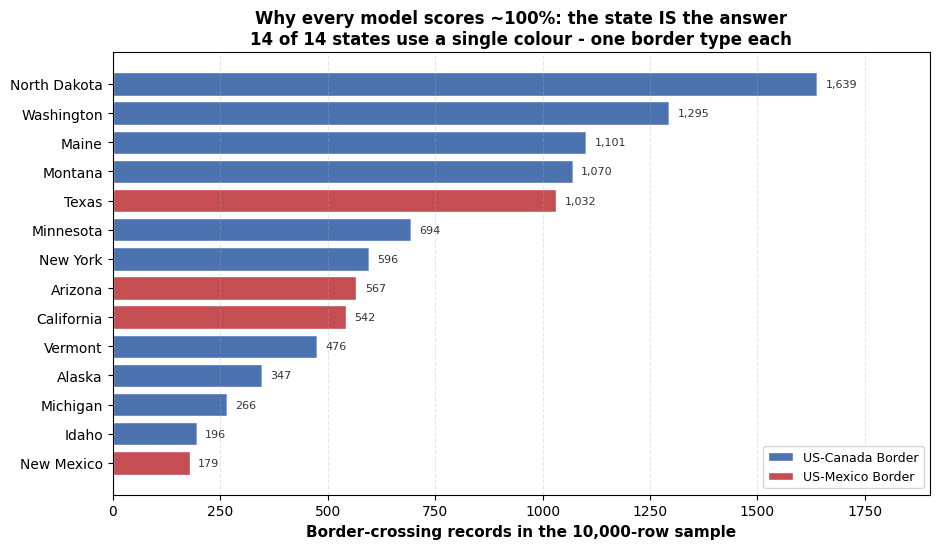


States whose records are ALL one border type: 14 of 14
   A model that memorises this 14-row lookup table scores ~100% without learning anything.


In [19]:
# CELL: Draw the leak the reality check just measured.
# WHY: "every state maps to exactly one border" is a sentence students can skim.
# One bar per state, coloured by border type, is a fact they cannot argue with.
import matplotlib.pyplot as plt

# Rebuild the state x border count table from the SAME arrays the check above used.
leak_df = pd.DataFrame({"state": X_data["State_encoded"].values, "border": y_data.values})
table = pd.crosstab(leak_df["state"], leak_df["border"])   # rows = states, cols = border types
table["total"] = table.sum(axis=1)
table = table.sort_values("total")                          # smallest state at the bottom of the chart

# Prefer real state / border names when the encoders from the loading cell exist.
if "le_state" in globals():
    row_labels = [str(s) for s in le_state.inverse_transform(table.index.values)]
else:
    row_labels = [f"state {int(s)}" for s in table.index.values]
class_codes = [c for c in table.columns if c != "total"]
if "le_border" in globals():
    class_labels = [str(le_border.classes_[int(c)]) for c in class_codes]
else:
    class_labels = [f"class {int(c)}" for c in class_codes]

palette = ["#4C72B0", "#C44E52", "#55A868", "#DD8452"]
fig, ax = plt.subplots(figsize=(9.5, 5.6))
ypos = np.arange(len(table))
left = np.zeros(len(table))
for k, code in enumerate(class_codes):
    vals = table[code].values.astype(float)
    ax.barh(ypos, vals, left=left, color=palette[k % len(palette)],
            edgecolor="white", label=class_labels[k])
    left += vals
for i, total in enumerate(table["total"].values):
    ax.text(total + table["total"].max() * 0.012, i, f"{int(total):,}",
            va="center", fontsize=8, color="#333333")

pure = int((table[class_codes] > 0).sum(axis=1).eq(1).sum())
ax.set_yticks(ypos)
ax.set_yticklabels(row_labels, fontsize=10)
ax.set_xlim(0, table["total"].max() * 1.16)
ax.set_xlabel(f"Border-crossing records in the {len(leak_df):,}-row sample",
              fontsize=11, fontweight="bold")
ax.set_title(f"Why every model scores ~100%: the state IS the answer\n"
             f"{pure} of {len(table)} states use a single colour - one border type each",
             fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3, axis="x", ls="--")
plt.tight_layout()
plt.show()

print(f"\nStates whose records are ALL one border type: {pure} of {len(table)}")
print("   A model that memorises this 14-row lookup table scores ~100% without learning anything.")


**Read the figure.** One horizontal bar per state, the bar split by border type and the record count
printed at its end. Every bar is a single colour: the blue states (North Dakota, Washington, Maine, Montana,
Minnesota, New York, Vermont, Alaska, Michigan, Idaho) are Canada-only, the red ones (Texas, Arizona,
California, New Mexico) are Mexico-only. Not one bar is split.

**What it proves:** `State_encoded` is not a feature, it is the answer written in a different column. Any
model that memorises this 14-row lookup scores ~100%, which is exactly what Grid Search, Random Search, the
SVM and the untuned baseline all did. This is what the flat search surface in the previous figure was made
of. On a dataset without the leak, the same search code would show real differences between combinations -
the mechanics you learned here are correct, the *scores* are the thing this dataset cannot teach.


PART 5: Visualize Grid Search Results

💡 Transition: Visualizing Grid Search results helps us understand how hyperparameters affect performance!
   Heatmaps show which parameter combinations work best.



✅ Plot saved as 'grid_search_heatmap.png'


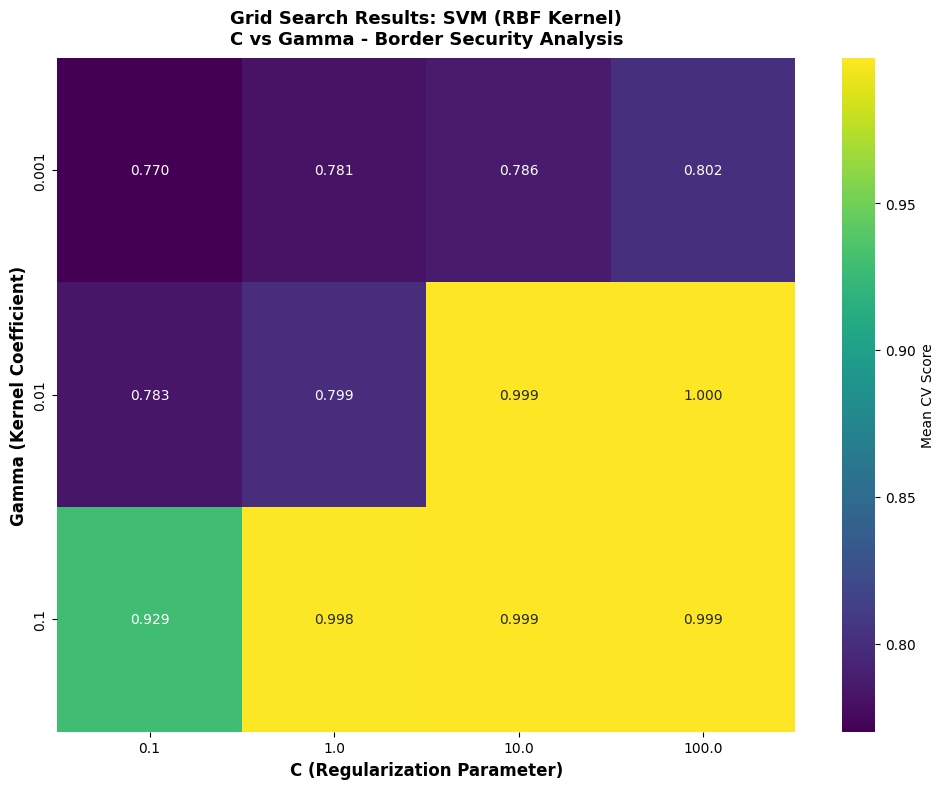


💡 DETAILED INTERPRETATION: Grid Search Heatmap

📊 WHAT YOU SEE:
   • Heatmap showing mean CV score for different C and gamma combinations
   • Colors: Brighter (yellow) = Higher performance, Darker (purple) = Lower performance
   • Each cell = One hyperparameter combination

🔍 HOW TO READ IT:
   • Find the brightest (yellow) cells = Best performing combinations
   • C axis (horizontal): Regularization strength
   • Gamma axis (vertical): Kernel influence radius
   • Numbers in cells = Mean CV score for that combination

💡 WHAT THIS TELLS US:
   • Which C and gamma values work best together
   • How sensitive the model is to hyperparameter changes
   • Optimal parameter region (brighter areas)

🎯 GDI APPLICATION - Border Security:
   • Identify optimal hyperparameters for border screening models
   • Balance between model complexity (C) and kernel influence (gamma)
   • Optimize threat detection accuracy for border security


In [20]:
# CELL: Heatmap of CV score across the C-gamma grid (RBF kernel only).
# WHY: a picture of the search space shows how sensitive SVM is to these two knobs.
print("\n" + "=" * 60)
print("PART 5: Visualize Grid Search Results")
print("=" * 60)
print("\n💡 Transition: Visualizing Grid Search results helps us understand how hyperparameters affect performance!")
print("   Heatmaps show which parameter combinations work best.")

# Extract results for visualization
results_df = pd.DataFrame(grid_search_svm.cv_results_)

# Filter for RBF kernel (most common)
rbf_results = results_df[results_df['param_kernel'] == 'rbf']

if len(rbf_results) > 0:
    # Create heatmap of C vs gamma
    pivot_table = rbf_results.pivot_table(
        values='mean_test_score', index='param_gamma',
        columns='param_C'
    )
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='viridis', 
                cbar_kws={'label': 'Mean CV Score'})
    plt.title('Grid Search Results: SVM (RBF Kernel)\nC vs Gamma - Border Security Analysis', fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('C (Regularization Parameter)', fontsize=12, fontweight='bold')
    plt.ylabel('Gamma (Kernel Coefficient)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grid_search_heatmap.png', dpi=300, bbox_inches='tight')
    print("\n✅ Plot saved as 'grid_search_heatmap.png'")
    plt.show()
    
    print("\n" + "=" * 70)
    print("💡 DETAILED INTERPRETATION: Grid Search Heatmap")
    print("=" * 70)
    print("\n📊 WHAT YOU SEE:")
    print("   • Heatmap showing mean CV score for different C and gamma combinations")
    print("   • Colors: Brighter (yellow) = Higher performance, Darker (purple) = Lower performance")
    print("   • Each cell = One hyperparameter combination")
    print("\n🔍 HOW TO READ IT:")
    print("   • Find the brightest (yellow) cells = Best performing combinations")
    print("   • C axis (horizontal): Regularization strength")
    print("   • Gamma axis (vertical): Kernel influence radius")
    print("   • Numbers in cells = Mean CV score for that combination")
    print("\n💡 WHAT THIS TELLS US:")
    print("   • Which C and gamma values work best together")
    print("   • How sensitive the model is to hyperparameter changes")
    print("   • Optimal parameter region (brighter areas)")
    print("\n🎯 GDI APPLICATION - Border Security:")
    print("   • Identify optimal hyperparameters for border screening models")
    print("   • Balance between model complexity (C) and kernel influence (gamma)")
    print("   • Optimize threat detection accuracy for border security")
else:
    print("\n⚠️  No RBF kernel results found for visualization")

**Read the heatmap.** Twelve cells, one per (C, gamma) pair on the RBF kernel. The whole top row
(gamma = 0.001) stays between 0.770 and 0.802, and six of the twelve cells sit below 0.81 - while five cells
reach 0.998 or higher, in the bottom-right corner where C and gamma are both large. Unlike the Random Forest
grid two sections ago, this surface is **not** flat: the SVM genuinely depends on its two knobs, and a bad
corner of this grid costs about 20 accuracy points.

**What it proves:** "hyperparameters do not matter" was a statement about the *forest on this dataset*, not
a law. Same data, different model family, and the grid suddenly has a shape worth searching. Note also where
the bright plateau tops out - 1.000 - which is the leaked state-to-border lookup, not a hard-won gain.

In [21]:
# Compare computation time (using smaller grid for demo)
print("\n" + "=" * 60)
print("PART 6: Computation Time Comparison")
print("=" * 60)
print("\n💡 Transition: Let's compare computation time between Grid Search and Random Search!")
print("   This helps us understand the efficiency trade-offs.")

# Use smaller grid and subset of data for faster demo
small_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

rf_small = RandomForestClassifier(random_state=73)  # Using 73 for consistency

# Grid Search timing
grid_small = GridSearchCV(rf_small, small_param_grid, cv=3, n_jobs=-1)
print("\n⏱️  Timing Grid Search (small grid, subset of data)...")
start_time = time.time()
grid_small.fit(X_train[:500], y_train[:500])  # Use subset for speed
grid_time = time.time() - start_time

# Random Search timing
random_small = RandomizedSearchCV(rf_small, small_param_grid, n_iter=4, 
                                   cv=3, n_jobs=-1, random_state=73)  # Using 73 for consistency
print("⏱️  Timing Random Search (same small grid, 4 iterations)...")
start_time = time.time()
random_small.fit(X_train[:500], y_train[:500])
random_time = time.time() - start_time

print(f"\n📊 Timing Results:")
print(f"   Grid Search Time: {grid_time:.2f} seconds")
print(f"   Random Search Time: {random_time:.2f} seconds")
print(f"   Speedup: {grid_time/random_time:.2f}x faster")
print(f"\n💡 Note: This demo uses a small subset. Full dataset differences are more pronounced!")


PART 6: Computation Time Comparison

💡 Transition: Let's compare computation time between Grid Search and Random Search!
   This helps us understand the efficiency trade-offs.

⏱️  Timing Grid Search (small grid, subset of data)...


⏱️  Timing Random Search (same small grid, 4 iterations)...

📊 Timing Results:
   Grid Search Time: 0.29 seconds
   Random Search Time: 0.17 seconds
   Speedup: 1.71x faster

💡 Note: This demo uses a small subset. Full dataset differences are more pronounced!


In [22]:
# Closing summary: what this lesson covered and the habits worth keeping.
print("\n" + "=" * 60)
print("✅ Example 1 Complete!")
print("=" * 60)
print("\n📚 What You Learned:")
print("   1. ✅ Grid Search - Systematic hyperparameter tuning (tries all combinations)")
print("   2. ✅ Random Search - Efficient hyperparameter tuning (tries random combinations)")
print("   3. ✅ How to use cross-validation in hyperparameter tuning")
print("   4. ✅ How to compare different tuning methods")
print("   5. ✅ How to visualize tuning results")
print("   6. ✅ Why (near-)perfect scores demand a data-leakage check before celebrating")
print("\n🎯 Key Takeaways:")
print("   - Grid Search: Thorough but slow (use for small spaces)")
print("   - Random Search: Fast and often effective (use for large spaces)")
print("   - Always use cross-validation for reliable evaluation")
print("   - Test on separate test set to validate tuning")
print("\n➡️  Next Steps:")
print("   - Try different hyperparameter ranges")
print("   - Experiment with other models")
print("   - See Example 2: Boosting (uses hyperparameter tuning)")


✅ Example 1 Complete!

📚 What You Learned:
   1. ✅ Grid Search - Systematic hyperparameter tuning (tries all combinations)
   2. ✅ Random Search - Efficient hyperparameter tuning (tries random combinations)
   3. ✅ How to use cross-validation in hyperparameter tuning
   4. ✅ How to compare different tuning methods
   5. ✅ How to visualize tuning results
   6. ✅ Why (near-)perfect scores demand a data-leakage check before celebrating

🎯 Key Takeaways:
   - Grid Search: Thorough but slow (use for small spaces)
   - Random Search: Fast and often effective (use for large spaces)
   - Always use cross-validation for reliable evaluation
   - Test on separate test set to validate tuning

➡️  Next Steps:
   - Try different hyperparameter ranges
   - Experiment with other models
   - See Example 2: Boosting (uses hyperparameter tuning)


## 💬 Discuss

1. **Everything scored ~100%, and the reason was leakage.** Before reading the Reality Check, what
   should have made you suspicious? Turn it into a rule you can apply mechanically: *"if test accuracy
   exceeds ___, I do ___ before reporting anything."* Defend your threshold — too low and you waste a
   day on every good model.

2. **Grid search tried 108 combinations, random search 20, and they found equally good parameters.**
   If Bergstra and Bengio are right that only a few hyperparameters matter, what does an exhaustive
   grid actually buy you? Name a situation where you would still pay for one.

3. **Suppose the client insists `State_encoded` is a legitimate feature and refuses to drop it.**
   Redesign the evaluation so the reported score stops being a lie. (Ask what the training and test
   folds currently have in common — and what Unit 2's `GroupKFold` was for.)


## Step 6: Summary and Next Steps

**BEFORE**: You've completed all Grid Search and Random Search steps.

**AFTER**: Summary of what you learned and how to apply hyperparameter tuning in your projects!

**Why this matters**: Consolidating knowledge helps you remember and apply hyperparameter tuning correctly!

---

## ❓ Common Student Questions

**Q: What's the difference between parameters and hyperparameters?**
- **Answer**: 
  - **Parameters**: Learned from data during training (e.g., coefficients in linear regression, weights in neural networks)
  - **Hyperparameters**: Set before training, control model behavior (e.g., C, gamma, max_depth, learning_rate)
  - **Key difference**: Parameters are learned, hyperparameters are tuned
  - **Example**: In SVM, C and gamma are hyperparameters (you set them), support vectors are parameters (model learns them)

**Q: Why not just use default hyperparameters?**
- **Answer**: Defaults are generic (work for average cases), but your data might need different values:
  - **Problem**: Defaults may not be optimal for your specific dataset
  - **Example**: Default C=1.0 for SVM might not be optimal → Grid Search finds best C for your data
  - **Impact**: Tuning hyperparameters can improve accuracy by 5-20% (significant improvement!)
  - **Rule**: Always tune hyperparameters for best performance

**Q: What's the difference between Grid Search and Random Search?**
- **Answer**: 
  - **Grid Search**: Tries ALL combinations systematically (thorough but slow)
  - **Random Search**: Tries random combinations (faster, often finds good solutions)
  - **Grid Search**: Guaranteed to find best (within grid), but slow for large grids
  - **Random Search**: Faster, often finds good solutions quickly, but may miss optimal
  - **Use Grid Search**: When you have few hyperparameters or small grids
  - **Use Random Search**: When you have many hyperparameters or large grids

**Q: Why is Grid Search slow?**
- **Answer**: Grid Search tries ALL combinations:
  - **Problem**: If you have 3 hyperparameters with 5 values each = 5×5×5 = 125 combinations
  - **Issue**: Each combination needs cross-validation (e.g., 5-fold CV) → 125 × 5 = 625 model trainings!
  - **Solution**: Use smaller grids or Random Search (tries random combinations, faster)
  - **Tip**: Start with coarse grid, then fine-tune around best result

**Q: How do I choose which hyperparameters to tune?**
- **Answer**: Focus on hyperparameters that most affect performance:
  - **SVM**: C (regularization), gamma (kernel influence)
  - **Random Forest**: n_estimators (number of trees), max_depth (tree depth)
  - **Neural Networks**: learning_rate, batch_size, number of layers
  - **Rule**: Start with 2-3 most important hyperparameters, add more if needed
  - **Tip**: Use domain knowledge or documentation to identify important hyperparameters

**Q: How many combinations should I try in Grid Search?**
- **Answer**: Balance between thoroughness and speed:
  - **Small grid**: 2-3 values per hyperparameter (fast, may miss optimal)
  - **Medium grid**: 4-5 values per hyperparameter (balanced)
  - **Large grid**: 10+ values per hyperparameter (slow, thorough)
  - **Rule of thumb**: Start with 3-5 values per hyperparameter, total < 100 combinations
  - **Tip**: Use Random Search for large grids, then fine-tune with Grid Search

**Q: What scoring metric should I use for hyperparameter tuning?**
- **Answer**: Use the metric that matters for your problem:
  - **Classification**: accuracy (default), precision, recall, F1, AUC
  - **Regression**: MSE, RMSE, MAE, R²
  - **Imbalanced data**: Use F1 or AUC instead of accuracy
  - **Rule**: Use the same metric you'll use for final evaluation
  - **Tip**: Can use multiple metrics, but optimize for one primary metric

**Q: Can I use Grid Search without cross-validation?**
- **Answer**: **Not recommended!** Cross-validation is essential:
  - **Problem**: Without CV, you might overfit to training data
  - **Issue**: Hyperparameters that work well on training data may not generalize
  - **Solution**: Always use cross-validation (GridSearchCV, RandomizedSearchCV)
  - **Rule**: CV gives reliable estimate of performance, prevents overfitting
  - **Note**: GridSearchCV automatically uses cross-validation (that's what "CV" means!)

---

## ⚠️ Where this breaks

- **Search optimises the metric you hand it, and cannot audit it.** 540 cross-validated fits could not
  see what one `groupby` saw. Before tuning, check for leakage; tuning first only makes the wrong
  number more precise.
- **Selecting the best of many candidates on a CV score biases that score upward.** Pick the best of
  108 and its CV number is optimistic by construction. The only honest report comes from a test set
  that took no part in the search — which is why the notebook keeps quoting test accuracy separately.
- **Grid cost is multiplicative and mostly wasted.** Four parameters at five values each with 5-fold CV
  is 2,500 fits, and most of that budget is spent varying dimensions that do not matter.
- **The assumption that must hold:** the cross-validation scheme is itself valid. Grouped rows,
  time-ordered rows and leaked features all defeat it — and the search will still terminate,
  confidently, with a "best" configuration.
- **The cheaper alternatives:** random search first to locate the promising region, then a small grid
  inside it; successive halving (`HalvingGridSearchCV`) or Bayesian optimisation when each fit is
  expensive. And when the untuned baseline already scores 100%, the correct next action is not a
  bigger grid — it is to go and find out why.


## Step 8: Decision Framework - Grid Search vs Random Search

**BEFORE**: You've learned how to use Grid Search, but when should you use Grid Search vs Random Search?

**AFTER**: You'll have a clear decision framework to choose the right hyperparameter tuning method!

**Why this matters**: Using the wrong search method can:
- **Waste computation** → Grid Search tries all combinations, may be unnecessary
- **Miss better parameters** → Random Search may miss optimal combinations
- **Poor efficiency** → Wrong method takes too long or doesn't find good parameters

---

### 🎯 Decision Framework: Grid Search vs Random Search

**Key Question**: Should I use **GRID SEARCH** or **RANDOM SEARCH** for hyperparameter tuning?

#### Decision Tree:

```
Do you need to tune hyperparameters?
├─ NO → No search needed ✅
│   └─ Why? Use default parameters or known good values
│
└─ YES → Check hyperparameter space:
    ├─ Few hyperparameters (<5)? → Check parameter ranges
    │   ├─ Small ranges (few values each)? → Use GRID SEARCH ✅
    │   │   └─ Why? Can try all combinations efficiently
    │   │
    │   └─ Large ranges (many values each)? → Use RANDOM SEARCH ✅
    │       └─ Why? Too many combinations for grid search
    │
    ├─ Many hyperparameters (≥5)? → Use RANDOM SEARCH ✅
    │   └─ Why? Grid search becomes too expensive
    │
    ├─ Need exhaustive search? → Use GRID SEARCH ✅
    │   └─ Why? Grid search tries all combinations
    │
    └─ Need faster results? → Use RANDOM SEARCH ✅
        └─ Why? Random search is faster, often finds good parameters
```

#### Detailed Decision Process:

```
Step 1: Number of Hyperparameters
├─ Few (<5) → Continue to Step 2
└─ Many (≥5) → Use RANDOM SEARCH ✅
    └─ Why? Grid search becomes computationally expensive

Step 2: Parameter Space Size
├─ Small space (few values per parameter) → Use GRID SEARCH ✅
│   └─ Why? Can try all combinations efficiently
│
└─ Large space (many values per parameter) → Use RANDOM SEARCH ✅
    └─ Why? Too many combinations for grid search

Step 3: Computational Resources
├─ Limited resources, need speed → Use RANDOM SEARCH ✅
│   └─ Why? Random search is faster
│
└─ Have resources, need best parameters → Use GRID SEARCH ✅
    └─ Why? Grid search is exhaustive

Step 4: Search Strategy
├─ Need exhaustive search (all combinations)? → Use GRID SEARCH ✅
└─ Need efficient search (sample combinations)? → Use RANDOM SEARCH ✅
```

---

### 📊 Comparison Table: Grid Search vs Random Search

| Aspect | Grid Search | Random Search | Winner |
|--------|-------------|---------------|--------|
| **Search Strategy** | Exhaustive (tries all combinations) | Random sampling | Grid (exhaustive) |
| **Speed** | Slow (tries all combinations) | Fast (samples combinations) | Random |
| **Best Parameters** | Guaranteed to find best in grid | May miss best, but often finds good | Grid (guaranteed) |
| **Computational Cost** | High (many combinations) | Low (fewer combinations) | Random |
| **Hyperparameter Count** | Good for <5 parameters | Good for any number | Random (scalable) |
| **Parameter Space** | Good for small spaces | Good for large spaces | Random (scalable) |
| **Best For** | Small spaces, few parameters | Large spaces, many parameters | Depends |

---

### ✅ When to Use Grid Search

**Use Grid Search when:**

1. **Few Hyperparameters** ✅
   - Less than 5 hyperparameters to tune
   - Grid search is manageable
   - **Example**: Tuning C and gamma for SVM (2 parameters)

2. **Small Parameter Space** ✅
   - Few values per parameter
   - Total combinations < 1000
   - **Example**: 3 values for C, 3 values for gamma = 9 combinations

3. **Need Exhaustive Search** ✅
   - Want to try all combinations
   - Need guaranteed best parameters in grid
   - **Example**: Critical application, need best parameters

4. **Have Computational Resources** ✅
   - Can afford to try all combinations
   - Time is not critical
   - **Example**: Research project, can run overnight

5. **Discrete Parameters** ✅
   - Parameters have discrete values
   - Easy to define grid
   - **Example**: max_depth = [3, 5, 7, 10]

---

### ✅ When to Use Random Search

**Use Random Search when:**

1. **Many Hyperparameters** ✅
   - 5+ hyperparameters to tune
   - Grid search becomes too expensive
   - **Example**: Tuning 10+ hyperparameters for neural networks

2. **Large Parameter Space** ✅
   - Many values per parameter
   - Total combinations > 1000
   - **Example**: 10 values for C, 10 for gamma = 100 combinations (still manageable, but if more...)

3. **Need Speed** ✅
   - Limited computational resources
   - Need results quickly
   - **Example**: Quick prototyping, limited time

4. **Continuous Parameters** ✅
   - Parameters are continuous
   - Hard to define grid
   - **Example**: Learning rate (0.0001 to 0.1, continuous)

5. **Some Parameters More Important** ✅
   - Some parameters matter more than others
   - Random search explores more efficiently
   - **Example**: Learning rate more important than batch size

---

### ❌ When NOT to Use Each Method

#### Don't use Grid Search when:
1. **Many Hyperparameters** ❌
   - 5+ parameters
   - Grid search becomes too expensive
   - **Use Instead**: Random Search

2. **Large Parameter Space** ❌
   - Many values per parameter
   - Too many combinations
   - **Use Instead**: Random Search

3. **Limited Resources** ❌
   - Can't afford many combinations
   - **Use Instead**: Random Search

4. **Continuous Parameters** ❌
   - Parameters are continuous
   - Hard to grid
   - **Use Instead**: Random Search

#### Don't use Random Search when:
1. **Need Guaranteed Best** ❌
   - Need to find best parameters in space
   - **Use Instead**: Grid Search

2. **Small Space** ❌
   - Few combinations (< 100)
   - Grid search is fast enough
   - **Use Instead**: Grid Search

3. **Few Parameters** ❌
   - Less than 3 parameters
   - Grid search is manageable
   - **Use Instead**: Grid Search

---

### 📊 Real-World Examples

#### Example 1: SVM Tuning (C and gamma) ✅ GRID SEARCH
- **Hyperparameters**: 2 (C, gamma)
- **Parameter Space**: Small (3 values each = 9 combinations)
- **Need**: Best parameters
- **Decision**: ✅ Use Grid Search
- **Reasoning**: Few parameters, small space, can try all combinations

#### Example 2: Neural Network Tuning (10+ parameters) ✅ RANDOM SEARCH
- **Hyperparameters**: 10+ (learning rate, batch size, layers, etc.)
- **Parameter Space**: Very large (thousands of combinations)
- **Need**: Good parameters quickly
- **Decision**: ✅ Use Random Search
- **Reasoning**: Many parameters, large space, need speed

#### Example 3: Random Forest (3 parameters) ✅ GRID SEARCH
- **Hyperparameters**: 3 (n_estimators, max_depth, min_samples_split)
- **Parameter Space**: Small (5 values each = 125 combinations)
- **Need**: Best parameters
- **Decision**: ✅ Use Grid Search
- **Reasoning**: Few parameters, manageable space, can try all

#### Example 4: XGBoost (6+ parameters) ✅ RANDOM SEARCH
- **Hyperparameters**: 6+ (learning_rate, max_depth, n_estimators, etc.)
- **Parameter Space**: Large (hundreds of combinations)
- **Need**: Good parameters efficiently
- **Decision**: ✅ Use Random Search
- **Reasoning**: Many parameters, large space, need efficiency

---

### ✅ Key Takeaways

1. **Few parameters → Grid Search** - Use when <5 parameters
2. **Many parameters → Random Search** - Use when ≥5 parameters
3. **Small space → Grid Search** - Use when <1000 combinations
4. **Large space → Random Search** - Use when >1000 combinations
5. **Need speed → Random Search** - Use when time is limited
6. **Need best → Grid Search** - Use when need exhaustive search
7. **Try both** - Sometimes try both, compare results

---

### 🎓 Practice Decision-Making

**Scenario 1**: Tuning SVM with C and gamma (3 values each)
- **Hyperparameters**: 2
- **Combinations**: 9 (small)
- **Decision**: ✅ Grid Search (few parameters, small space)

**Scenario 2**: Tuning neural network with 8 hyperparameters
- **Hyperparameters**: 8
- **Combinations**: Thousands
- **Decision**: ✅ Random Search (many parameters, large space)

**Scenario 3**: Tuning Random Forest with 4 parameters (need best)
- **Hyperparameters**: 4
- **Combinations**: 256 (manageable)
- **Decision**: ✅ Grid Search (few parameters, manageable space, need best)

---

**Connection to Next Steps**: 
- 📓 **Example 2: Boosting** - Uses hyperparameter tuning for XGBoost and LightGBM
- 📓 **All ML Models** - Hyperparameter tuning improves all models
- 📓 **Production Systems** - Proper tuning is critical for performance

## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

Grid and random search are still the mechanism underneath every AutoML system — AutoGluon's stacked
ensembles included (Erickson et al., 2020, arXiv:2003.06505) — and running one by hand is how you learn
what a hyperparameter actually does. What changed is the order of operations: practitioners now measure
a strong no-tuning baseline first, and spend search budget only on the gap it leaves. Two recent results
make the point. TabArena, a living tabular benchmark, finds that the validation scheme and the ensembling
of hyperparameter configurations move results as much as the search itself does (Erickson et al., 2025,
arXiv:2506.16791); and the authors of TabPFN-3 report beating gradient-boosted-tree baselines that had
been tuned for eight hours, using a single forward pass and no tuning at all (Grinsztajn et al., 2026,
arXiv:2605.13986) — their own numbers, on datasets that are not yours, from a model that needs
downloaded weights and so cannot run here. The habit this lesson already teaches is the one that
survives all of it, and "Where this breaks" states it: search only optimises the number you hand it, so
fix an honest baseline and a valid cross-validation scheme before spending 540 fits improving it.

## 📚 References

1. Bergstra, J., & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. Journal of Machine Learning Research, 13, 281–305.
2. Snoek, J., Larochelle, H., & Adams, R. P. (2012). *Practical Bayesian Optimization of Machine Learning Algorithms*. NeurIPS 25. <https://arxiv.org/abs/1206.2944>
3. Bischl, B., et al. (2023). *Hyperparameter Optimization: Foundations, Algorithms, Best Practices and Open Challenges*. WIREs Data Mining and Knowledge Discovery, 13(2). <https://arxiv.org/abs/2107.05847>
4. Erickson, N., Mueller, J., Shirkov, A., et al. (2020). *AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data*. <https://arxiv.org/abs/2003.06505>
5. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. <https://arxiv.org/abs/2506.16791>
6. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. <https://arxiv.org/abs/2605.13986>
